In [2]:
# imports
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import numpy as np
from skimage.feature import peak_local_max
from skimage.restoration import denoise_nl_means, estimate_sigma

In [3]:
# 0: channel 640, 1: channel 488, 2 Bright Field, 3: folder name
data = []

dir = os.getcwd()
dir_data = os.getcwd()[:dir.rfind('\\')] + "\\data"
for folder in os.listdir(dir_data):
    new_img = [None, None, None, folder]
    for file in os.listdir(os.path.join(dir_data, folder)):
        if str(file).endswith("colour0.tif"):
            tempImg = mpimg.imread(os.path.join(dir_data, folder, file))
            # new_img[0] = np.array(tempImg)
            new_img[0] = np.array([i[tempImg.shape[1]//2:tempImg.shape[1]] for i in tempImg])
        elif str(file).endswith("colour1.tif"):
            tempImg = mpimg.imread(os.path.join(dir_data, folder, file))
            # new_img[1] = np.array(tempImg)
            new_img[1] = np.array([i[:tempImg.shape[1]//2] for i in tempImg])
        elif str(file).endswith("colour2.tif"):
            tempImg = mpimg.imread(os.path.join(dir_data, folder, file))
            # new_img[2] = np.array(tempImg)
            new_img[2] = np.array([i[:tempImg.shape[1]//2] for i in tempImg])
    data.append(new_img)
data.sort(key = lambda x : int(x[3].split("_")[1]))

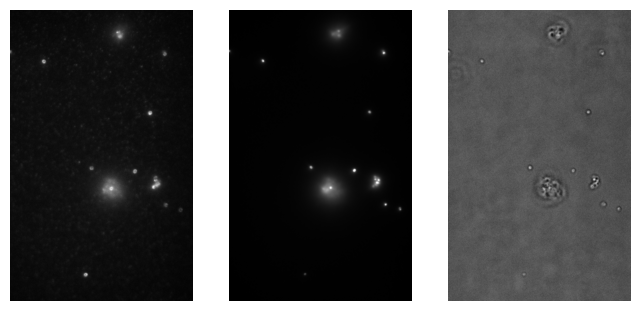

In [4]:
# image read function
def printImg(imgs, map=None):
    fig = plt.figure(figsize=(8,15))
    for i in range(3):
        plt.subplot(1, 3, i+1)
        plt.imshow(imgs[i], cmap=map)
        plt.axis('off')
data_i = data[1][0:3].copy()
printImg(data_i, "gray")

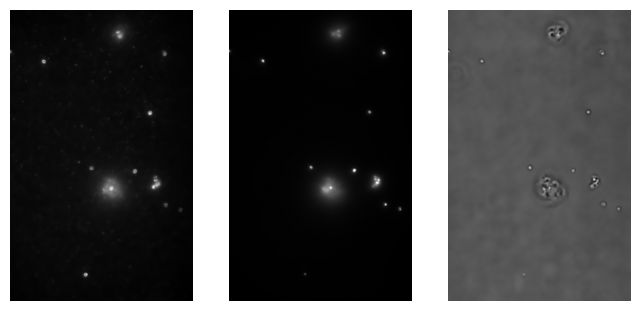

In [5]:
# denoise
imgs_denoise = data_i.copy()
patch_kw = dict(patch_size=5, patch_distance=6, channel_axis=None)
for i in range(len(imgs_denoise)):
    imgs_i = imgs_denoise[i].copy()
    sigma_est = np.mean(estimate_sigma(imgs_i, channel_axis=None))
    denoise_fast = denoise_nl_means(imgs_i, h=1.5 * sigma_est, fast_mode=True, preserve_range=True, **patch_kw)

    imgs_denoise[i] =  denoise_fast
printImg(imgs_denoise, "gray")

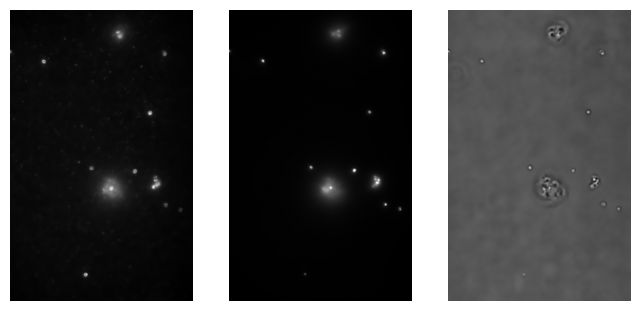

In [6]:
# normalise to 0 - 255
imgs_norm = imgs_denoise.copy()
for i in range(3):
    normalized_image = cv2.normalize(imgs_norm[i], None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
    imgs_norm[i] = normalized_image
printImg(imgs_norm, "gray")

12.78002639359589
3.392589380679141
87.81504182721167


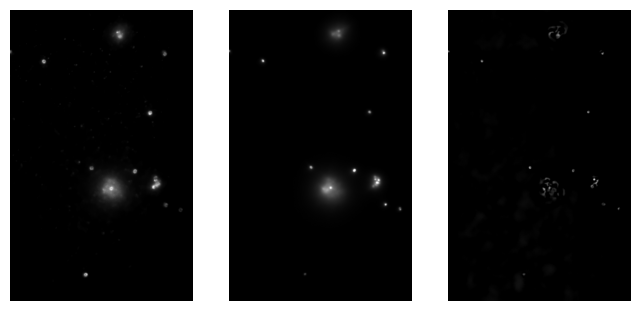

In [9]:
# boundary threshold
# quartile
imgs_thresh = imgs_norm.copy()
thresh_list = [80, 80, 80]
for i in range(len(imgs_thresh)):
    imgs_i = imgs_thresh[i].copy()
    qtl_i = np.percentile(imgs_i, thresh_list[i])
    print(qtl_i)
    threshold = qtl_i # 65535
    imgs_i[imgs_i < qtl_i] = qtl_i
    # bound = cv2.inRange(imgsTest[i], int(np.amin(imgsTest[i]))-10, int(np.amax(imgsTest[i]))+10)
    imgs_thresh[i] =  imgs_i
printImg(imgs_thresh, "gray")
# mean
# for i in range(5):
#     for i in range(len(imgs_thresh)):
#         imgs_i = imgs_thresh[i].copy()
#         mean = np.mean(imgs_i)
#         print(mean)
#         imgs_i[imgs_i < mean] = mean
#         # bound = cv2.inRange(imgsTest[i], int(np.amin(imgsTest[i]))-10, int(np.amax(imgsTest[i]))+10)
#         imgs_thresh[i] =  imgs_i
# printImg(imgs_thresh, "gray")

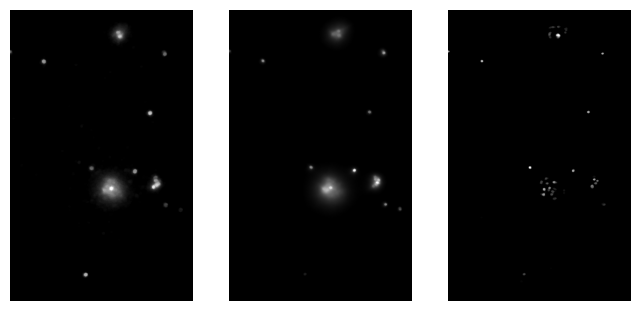

In [221]:
# Opening: erosion followed by dilation, removes small objects
# kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
kernel = np.ones((3, 3), np.uint8)
imgs_opening = imgs_thresh.copy()

for i in range(len(imgs_opening)):
    imgs_i = imgs_opening[i].copy()
    opening = cv2.morphologyEx(imgs_opening[i], cv2.MORPH_OPEN, kernel)
    img_erosion = cv2.erode(imgs_i, kernel, iterations=1)
    img_dilation = cv2.dilate(img_erosion, kernel, iterations=1)
    imgs_opening[i] = opening
printImg(imgs_opening, "gray")

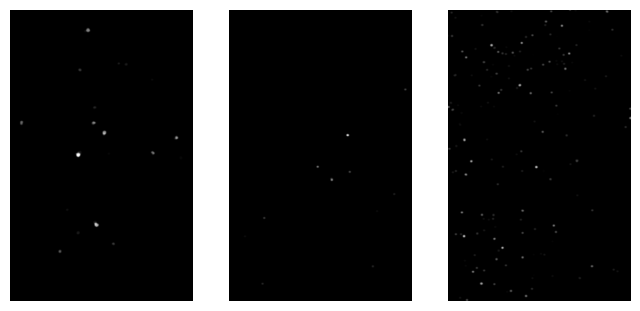

In [208]:
# test blur
imgsTest_blur = imgs_opening.copy()
for i in range(len(imgsTest_blur)):
    blur = cv2.GaussianBlur(imgsTest_blur[i],(3,3), 4)
    imgsTest_blur[i] = blur
printImg(imgsTest_blur, "gray")

248839
263476
234201


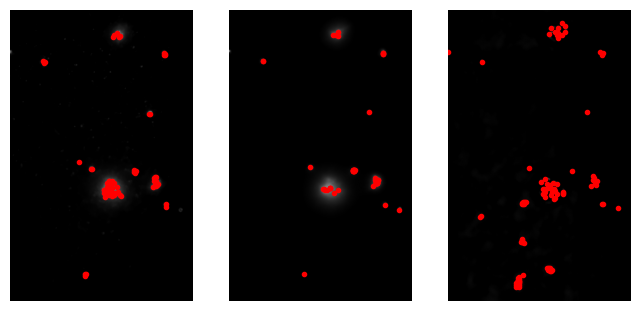

In [49]:
# test peak
img_peak = imgs_thresh.copy()
fig = plt.figure(figsize=(8,15))
for i in range(len(img_peak)):
    plt.subplot(1, 3, i+1)
    test = np.sum(img_peak[i] == np.min(img_peak[i])) np.sum(img_peak[i] == np.min(img_peak[i]))
    print(test)
    thresh = np.min(img_peak[i])
    qtl_i = np.percentile(img_peak[i], 99)
    peaks = peak_local_max(img_peak[i], threshold_abs=qtl_i)
    plt.imshow(img_peak[i], cmap=plt.cm.gray)
    plt.plot(peaks[:, 1], peaks[:, 0], 'r.')
    plt.axis('off')
    plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

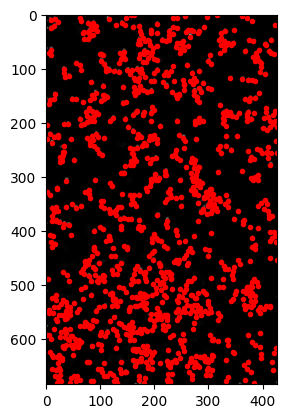

In [44]:
img_peak = imgs_thresh[2].copy()
peaks = peak_local_max(img_peak, threshold_abs=np.percentile(img_peak, 90))
plt.imshow(img_peak, cmap=plt.cm.gray)
plt.plot(peaks[:, 1], peaks[:, 0], 'r.')
plt.show

In [ ]:
# watershed

import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)
ret, thresh = cv.threshold(gray,0,255,cv.THRESH_BINARY_INV+cv.THRESH_OTSU)